### 1. Load the Dataset  
Loads the dataset from the given path and displays the first few rows for inspection.


In [1]:
import pandas as pd

print("Loading dataset...")
data_path = "/kaggle/input/prediction-of-sepsis/Dataset.csv"
df = pd.read_csv(data_path)
print("First 5 rows of the dataset:")
print(df.head())


Loading dataset...
First 5 rows of the dataset:
   Unnamed: 0  Hour    HR  O2Sat  Temp    SBP   MAP   DBP  Resp  EtCO2  ...  \
0           0     0   NaN    NaN   NaN    NaN   NaN   NaN   NaN    NaN  ...   
1           1     1  65.0  100.0   NaN    NaN  72.0   NaN  16.5    NaN  ...   
2           2     2  78.0  100.0   NaN    NaN  42.5   NaN   NaN    NaN  ...   
3           3     3  73.0  100.0   NaN    NaN   NaN   NaN  17.0    NaN  ...   
4           4     4  70.0  100.0   NaN  129.0  74.0  69.0  14.0    NaN  ...   

   Fibrinogen  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  ICULOS  \
0         NaN        NaN  68.54       0    NaN    NaN        -0.02       1   
1         NaN        NaN  68.54       0    NaN    NaN        -0.02       2   
2         NaN        NaN  68.54       0    NaN    NaN        -0.02       3   
3         NaN        NaN  68.54       0    NaN    NaN        -0.02       4   
4         NaN      330.0  68.54       0    NaN    NaN        -0.02       5   

   Sepsi

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


### 2. Define Features and Target  
Drops unnecessary columns and sets the target variable (`SepsisLabel`). Shows feature matrix shape and class distribution.


In [2]:
print("Dropping unnecessary columns and defining features and target...")
df = df.drop(columns=['patient_id'], errors='ignore')
target_col = 'SepsisLabel'
X_raw = df.drop(columns=[target_col])
y = df[target_col]

print(f"Shape of feature matrix: {X_raw.shape}")
print(f"Target distribution:\n{y.value_counts()}")


Dropping unnecessary columns and defining features and target...
Shape of feature matrix: (1552210, 43)
Target distribution:
SepsisLabel
0    1524294
1      27916
Name: count, dtype: int64


### 3. Handle Missing Values  
Uses median imputation to fill missing values in the feature set.


In [3]:
from sklearn.impute import SimpleImputer

print("Imputing missing values using median strategy...")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

print("Missing values after imputation:")
print(X_imputed.isnull().sum().sum())


Imputing missing values using median strategy...
Missing values after imputation:
0


### Standardize Features  
Scales all features to have zero mean and unit variance using StandardScaler.


In [4]:
from sklearn.preprocessing import StandardScaler

print("Standardizing features...")
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)

print("Feature matrix after standardization (first 5 rows):")
print(X_scaled.head())


Standardizing features...
Feature matrix after standardization (first 5 rows):
   Unnamed: 0      Hour        HR     O2Sat      Temp       SBP       MAP  \
0   -0.882635 -0.882635 -0.059244  0.254653  0.017198 -0.109313 -0.137238   
1   -0.848012 -0.848012 -1.183861  0.981435  0.017198 -0.109313 -0.659735   
2   -0.813389 -0.813389 -0.393590  0.981435  0.017198 -0.109313 -2.586445   
3   -0.778766 -0.778766 -0.697540  0.981435  0.017198 -0.109313 -0.137238   
4   -0.744143 -0.744143 -0.879911  0.981435  0.017198  0.262891 -0.529111   

        DBP      Resp     EtCO2  ...       WBC  Fibrinogen  Platelets  \
0 -0.108390 -0.130901  0.001026  ... -0.037154   -0.019286  -0.034967   
1 -0.108390 -0.450200  0.001026  ... -0.037154   -0.019286  -0.034967   
2 -0.108390 -0.130901  0.001026  ... -0.037154   -0.019286  -0.034967   
3 -0.108390 -0.343767  0.001026  ... -0.037154   -0.019286  -0.034967   
4  0.495331 -0.982365  0.001026  ...  0.468696   -0.019286   5.806531   

        Age   Gende

### Train-Test Split  
Splits the dataset into training and testing sets with stratification to maintain class balance.


In [6]:
from sklearn.model_selection import train_test_split

print("Splitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")


Splitting data into train and test sets...
Train set shape: (1241768, 20)
Test set shape: (310442, 20)


## Exploratory Data Analysis (EDA)

Performing Enhanced Exploratory Data Analysis (EDA)...
Visualizing distribution of SepsisLabel...


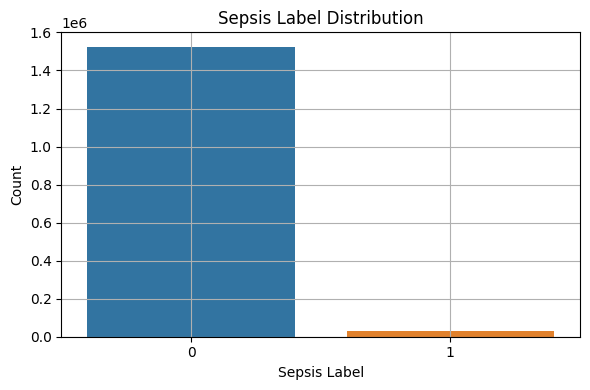

Generating correlation heatmap...


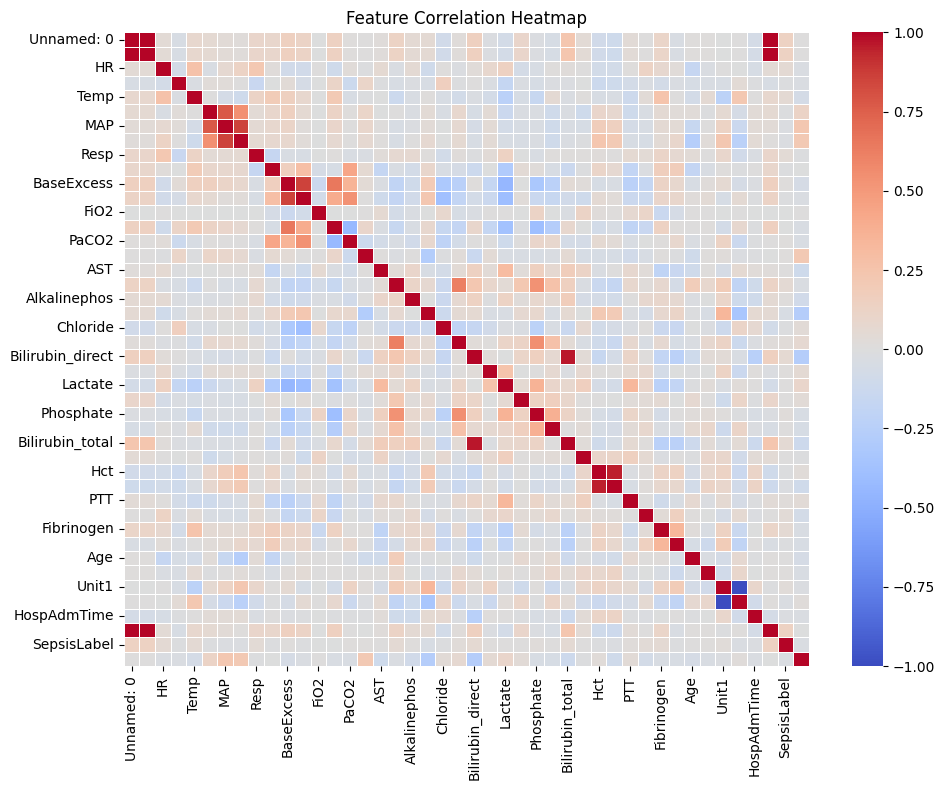

Generating pairwise feature distributions (pairplot)...


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

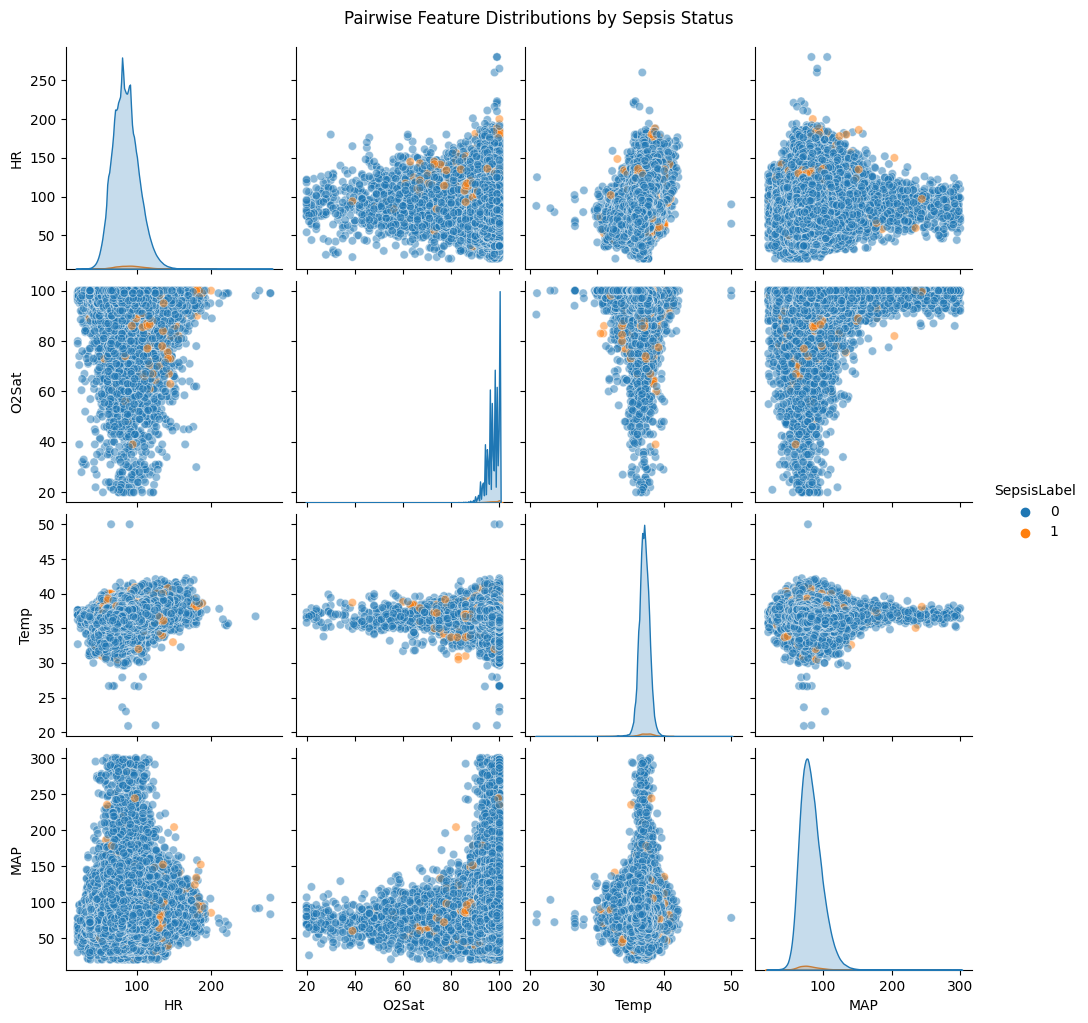

Generating violin plots...


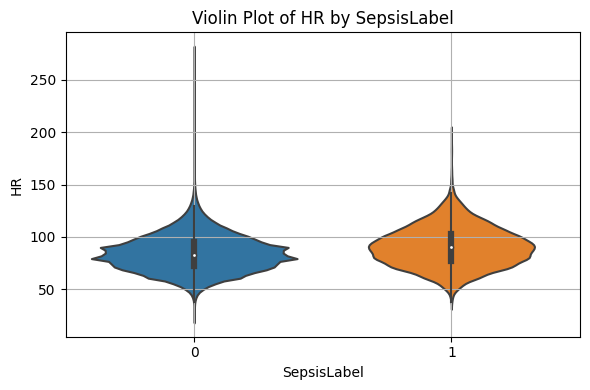

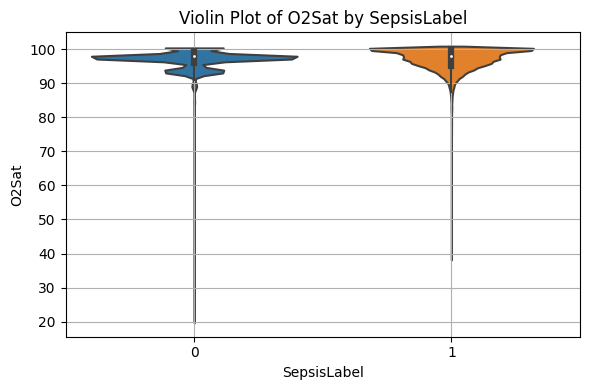

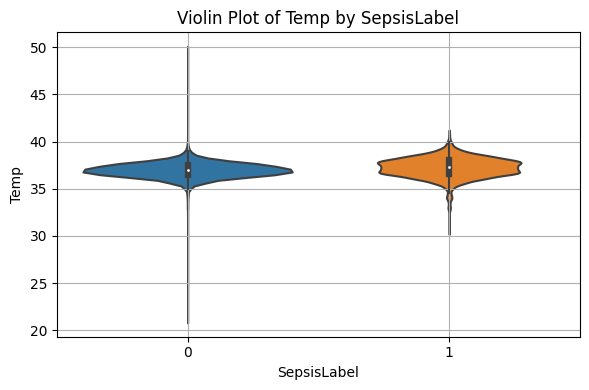

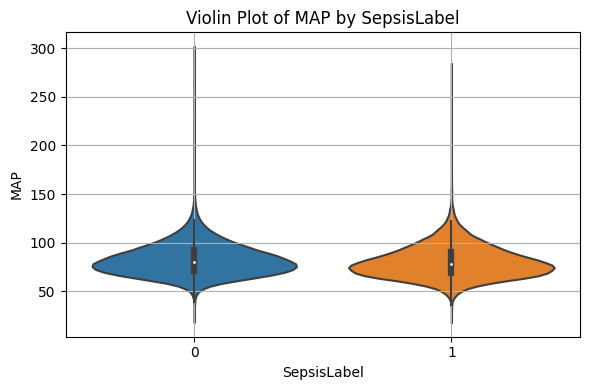

Generating box plots...


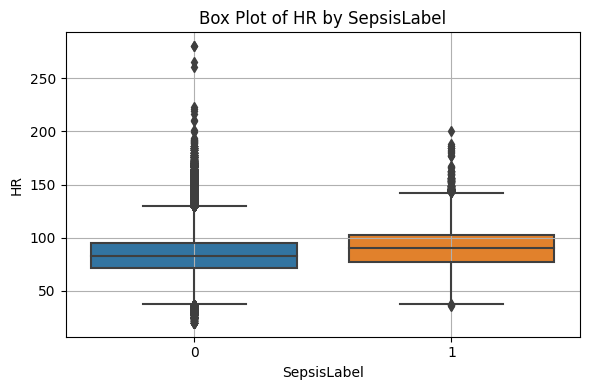

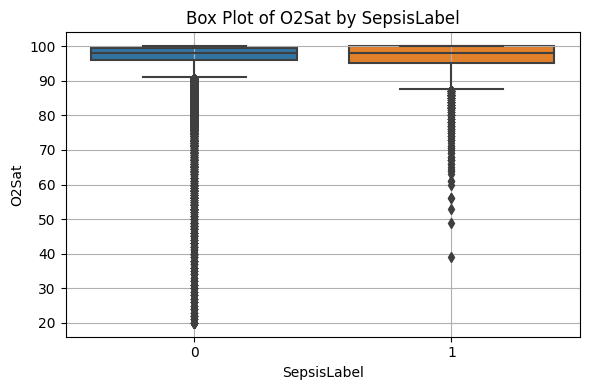

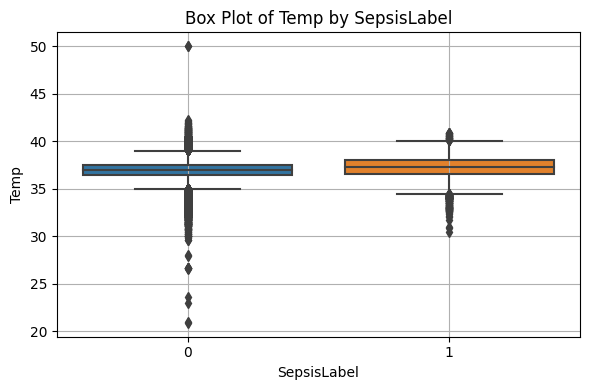

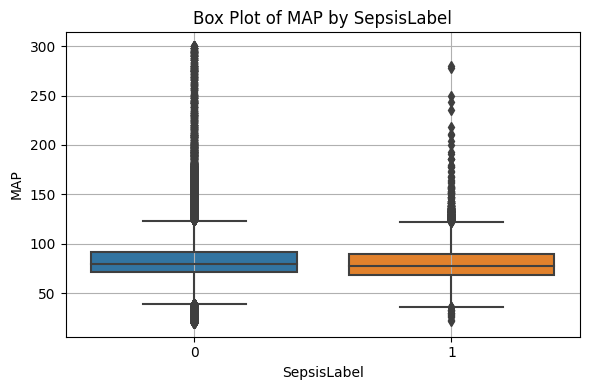

Generating line plot of mean trends by label...


<Figure size 800x500 with 0 Axes>

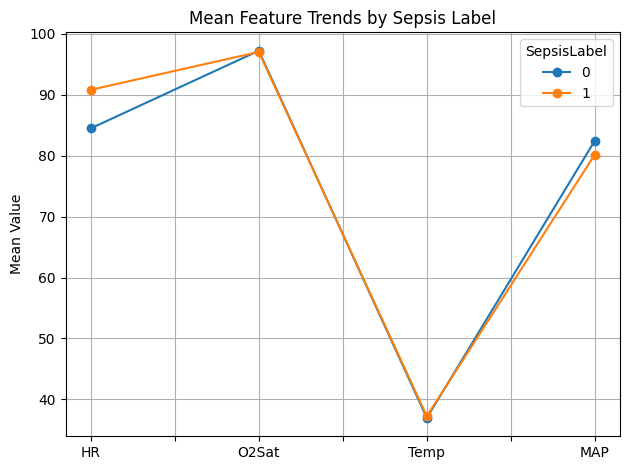

Generating scatter plot...


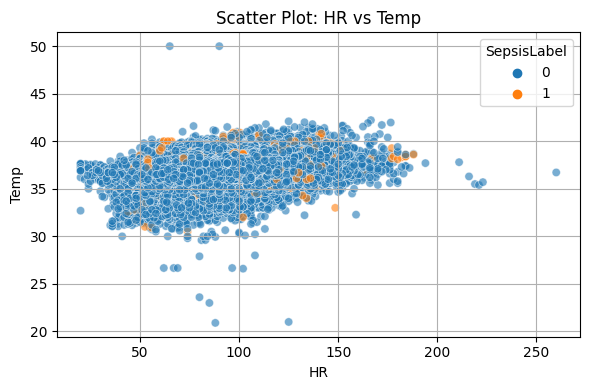

Generating histograms...


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


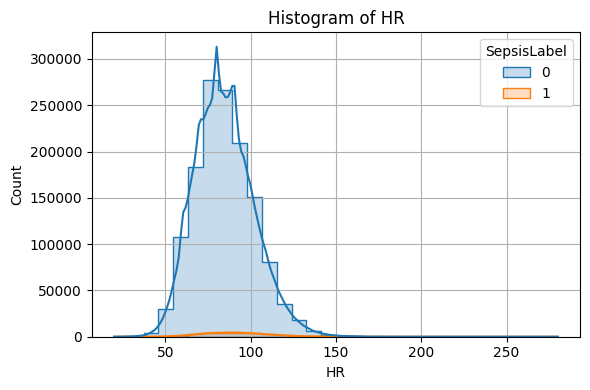

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


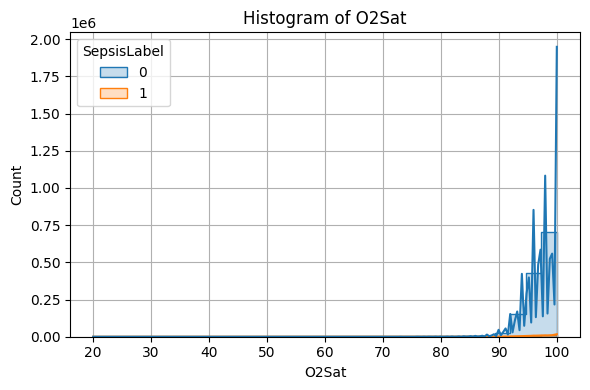

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


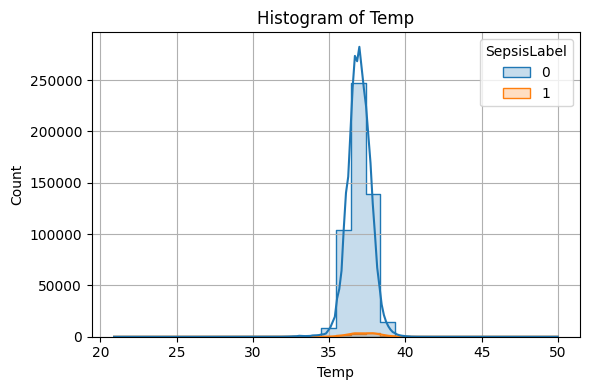

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


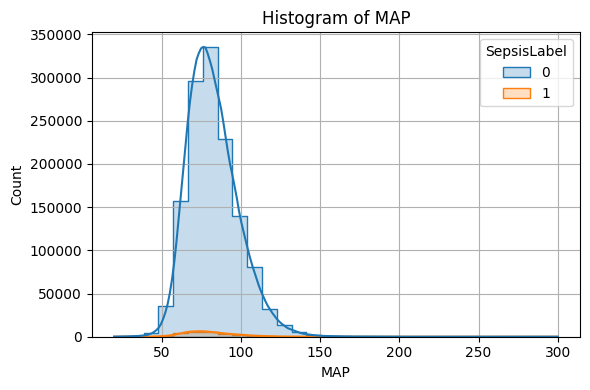

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Performing Enhanced Exploratory Data Analysis (EDA)...")

# ---- 1. Visualizing distribution of SepsisLabel ----
print("Visualizing distribution of SepsisLabel...")
plt.figure(figsize=(6, 4))
sns.countplot(x='SepsisLabel', data=df)
plt.title("Sepsis Label Distribution")
plt.xlabel("Sepsis Label")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- 2. Generating correlation heatmap ----
print("Generating correlation heatmap...")
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# ---- 3. Pairwise feature distributions ----
print("Generating pairwise feature distributions (pairplot)...")
selected_features = ['HR', 'O2Sat', 'Temp', 'MAP', 'SepsisLabel']
sns.pairplot(df[selected_features], hue='SepsisLabel', plot_kws={'alpha': 0.5})
plt.suptitle("Pairwise Feature Distributions by Sepsis Status", y=1.02)
plt.show()

# ---- 4. Violin plots ----
print("Generating violin plots...")
for feature in ['HR', 'O2Sat', 'Temp', 'MAP']:
    plt.figure(figsize=(6, 4))
    sns.violinplot(x='SepsisLabel', y=feature, data=df)
    plt.title(f"Violin Plot of {feature} by SepsisLabel")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---- 5. Box plots ----
print("Generating box plots...")
for feature in ['HR', 'O2Sat', 'Temp', 'MAP']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='SepsisLabel', y=feature, data=df)
    plt.title(f"Box Plot of {feature} by SepsisLabel")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---- 6. Line plot (mean feature trends) ----
print("Generating line plot of mean trends by label...")
plt.figure(figsize=(8, 5))
df.groupby('SepsisLabel')[['HR', 'O2Sat', 'Temp', 'MAP']].mean().T.plot(marker='o')
plt.title("Mean Feature Trends by Sepsis Label")
plt.ylabel("Mean Value")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- 7. Scatter plot (HR vs Temp) ----
print("Generating scatter plot...")
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='HR', y='Temp', hue='SepsisLabel', alpha=0.6)
plt.title("Scatter Plot: HR vs Temp")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- 8. Histogram of key features ----
print("Generating histograms...")
features = ['HR', 'O2Sat', 'Temp', 'MAP']
for feature in features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=feature, hue='SepsisLabel', kde=True, bins=30, element="step")
    plt.title(f"Histogram of {feature}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Compute Sample Weights and Split Data  
Calculates balanced class weights and performs a two-stage split: 85/15 for test, then 85/15 for train-validation sets.


In [3]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split

print("Computing sample weights using class balance...")
sample_weights = compute_sample_weight(class_weight="balanced", y=y)

print("Performing initial train-test split (85% temp, 15% test)...")
X_temp, X_test, y_temp, y_test, sw_temp, sw_test = train_test_split(
    X_scaled, y, sample_weights, test_size=0.15, stratify=y, random_state=42
)

print("Performing train-validation split from temp set (85% train, 15% validation)...")
X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X_temp, y_temp, sw_temp, test_size=0.15, stratify=y_temp, random_state=42
)

print(f"Shapes:")
print(f"  Train:      {X_train.shape}, Labels: {y_train.shape}, Weights: {w_train.shape}")
print(f"  Validation: {X_val.shape}, Labels: {y_val.shape}, Weights: {w_val.shape}")
print(f"  Test:       {X_test.shape}, Labels: {y_test.shape}, Weights: {sw_test.shape}")


Computing sample weights using class balance...


NameError: name 'y' is not defined

## Load and Preprocess the Dataset

This section loads the raw data, removes irrelevant columns, handles missing values using median imputation, and standardizes the features using `StandardScaler` to ensure all input features have zero mean and unit variance.


In [4]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("Loading and preprocessing dataset...")
df = pd.read_csv("/kaggle/input/prediction-of-sepsis/Dataset.csv")
df = df.drop(columns=['patient_id', 'timestamp_epoch', 'datetime'], errors='ignore')

X_raw = df.drop(columns=['SepsisLabel'])
y = df['SepsisLabel']

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)


Loading and preprocessing dataset...


## Feature Selection Using XGBoost

This section uses an XGBoost classifier to evaluate feature importance and selects the top 30 most important features based on their contribution to the model's predictive performance. These selected features are used for subsequent modeling.


In [5]:
from xgboost import XGBClassifier

print("Selecting top 30 features using XGBoost...")
xgb_fs = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_fs.fit(X_scaled, y)

importances = pd.Series(xgb_fs.feature_importances_, index=X_scaled.columns)
top_features = importances.sort_values(ascending=False).head(30).index.tolist()
X = X_scaled[top_features]


Selecting top 30 features using XGBoost...


## Clean Column Names

This section ensures that all feature names are compatible with libraries such as LightGBM and CatBoost by removing or replacing special characters (e.g., quotes, brackets, colons) from the column names. Clean column names help prevent parsing errors during model training.


In [6]:
print("Cleaning column names...")
def clean_column_names(df):
    return [col.replace('"', '').replace('\\', '').replace(' ', '_')
                .replace('[', '').replace(']', '')
                .replace('{', '').replace('}', '')
                .replace(':', '').replace(',', '') for col in df.columns]

X.columns = clean_column_names(X)

Cleaning column names...


## Balance the Dataset Using Undersampling

This section addresses class imbalance by performing manual undersampling of the majority class. It randomly samples the majority class (`SepsisLabel = 0`) to match the number of instances in the minority class (`SepsisLabel = 1`). The resulting dataset has an equal number of samples for each class, ensuring a balanced distribution for training.


In [7]:
df_bal = pd.concat([X, y], axis=1)
class_0 = df_bal[df_bal['SepsisLabel'] == 0]
class_1 = df_bal[df_bal['SepsisLabel'] == 1]
class_0_down = class_0.sample(n=len(class_1), random_state=42)
df_balanced = pd.concat([class_1, class_0_down]).sample(frac=1, random_state=42)
X_bal = df_balanced.drop(columns=['SepsisLabel'])
y_bal = df_balanced['SepsisLabel']

print("Balanced dataset class distribution:")
print(y_bal.value_counts())

Balanced dataset class distribution:
SepsisLabel
1    27916
0    27916
Name: count, dtype: int64


## Split the Balanced Data into Training and Holdout Sets

This section splits the balanced dataset into training and holdout sets using an 80-20 split. Stratified sampling is used to maintain class balance in both subsets, ensuring that the distribution of target classes remains consistent across the training and validation sets.


In [8]:
from sklearn.model_selection import train_test_split

X_base, X_holdout, y_base, y_holdout = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42
)

## Create a Custom Balanced Test Set

This section constructs a custom test set with nearly equal representation of both classes to enable fair evaluation. It samples 5,584 instances from class 0 and 5,583 instances from class 1, then combines and shuffles them to form a balanced test dataset for performance assessment.


In [9]:
print("Creating custom test set:")
test_df = pd.concat([X, y], axis=1)
class_0 = test_df[test_df['SepsisLabel'] == 0].sample(n=5584, random_state=42)
class_1 = test_df[test_df['SepsisLabel'] == 1].sample(n=5583, random_state=42)
test_balanced_df = pd.concat([class_0, class_1]).sample(frac=1, random_state=42)
X_test_balanced = test_balanced_df.drop(columns=['SepsisLabel'])
y_test_balanced = test_balanced_df['SepsisLabel']

Creating custom test set:


## Train Base Models for Stacking

This section trains three different base classifiers—Logistic Regression, Random Forest, and Gradient Boosting—on the balanced training data. Each model is fitted independently, and their probability predictions on the holdout set are stored for use as meta-features in the next stage of the stacking process.


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

print("Training base models: Logistic Regression, Random Forest, Gradient Boosting...")
base_models = [
    ('log_reg', LogisticRegression(max_iter=500)),
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gbc', GradientBoostingClassifier(n_estimators=100, random_state=42))
]

base_preds = []
for name, model in base_models:
    print(f"Training {name}...")
    model.fit(X_base, y_base)
    pred = model.predict_proba(X_holdout)[:, 1]
    base_preds.append(pred)


Training base models: Logistic Regression, Random Forest, Gradient Boosting...
Training log_reg...
Training random_forest...
Training gbc...


## Create Meta-Feature Matrix for Stacking

This section constructs the meta-feature matrix by stacking the probability predictions from each base model on the holdout set. These meta-features (`meta_X`) along with the corresponding true labels (`meta_y`) will be used to train the meta-learner in the next step of the stacking ensemble.


In [ ]:
import numpy as np

print("Stacking base model predictions...")
meta_X = np.column_stack(base_preds)
meta_y = y_holdout

Stacking base model predictions...


## Train the Meta-Learner

This section trains the meta-learner using an XGBoost classifier. The meta-learner takes the stacked predictions from the base models as input (`meta_X`) and learns to make final predictions based on them. XGBoost is configured with parameters suitable for balanced data and is trained to optimize the AUC metric.


In [12]:
print("Training meta-learner...")
meta_model = XGBClassifier(
    learning_rate=0.05,
    n_estimators=1000,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    scale_pos_weight=1,
    random_state=42
)
meta_model.fit(meta_X, meta_y)

Training meta-learner...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

## Evaluate the Stacked Model on the Custom Test Set

This section evaluates the final stacked model using a custom balanced test set. It computes the predicted probabilities, tunes the decision threshold to maximize the F1-score, and reports key classification metrics. A confusion matrix is also displayed to visualize true positives, false positives, true negatives, and false negatives. The ROC AUC score provides a summary of the model's overall discrimination ability.


Evaluating final model on custom balanced test set...

Optimal Threshold for F1: 0.521

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5584
           1       0.98      0.98      0.98      5583

    accuracy                           0.98     11167
   macro avg       0.98      0.98      0.98     11167
weighted avg       0.98      0.98      0.98     11167

ROC AUC Score: 0.9983226075935594


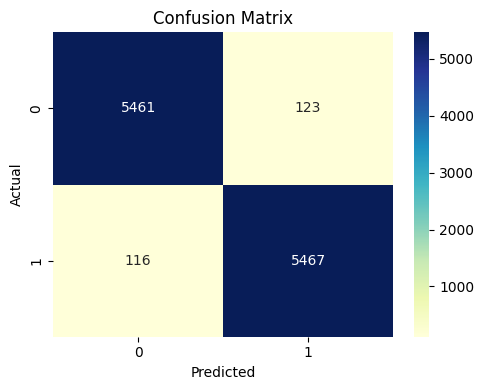

In [15]:
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluating final model on custom balanced test set...")
base_test_preds = [model.predict_proba(X_test_balanced)[:, 1] for _, model in base_models]
meta_test_X = np.column_stack(base_test_preds)
y_scores = meta_model.predict_proba(meta_test_X)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test_balanced, y_scores)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores)]

print(f"\nOptimal Threshold for F1: {best_thresh:.3f}")
final_preds = (y_scores >= best_thresh).astype(int)

print("\nClassification Report:")
print(classification_report(y_test_balanced, final_preds))
print("ROC AUC Score:", roc_auc_score(y_test_balanced, y_scores))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_balanced, final_preds), annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## Visualize Model Performance

This section includes visualizations to assess the model’s effectiveness, including the confusion matrix, ROC curve, precision-recall curve, and predicted probability distributions. These plots help evaluate classification quality, threshold behavior, and prediction confidence.


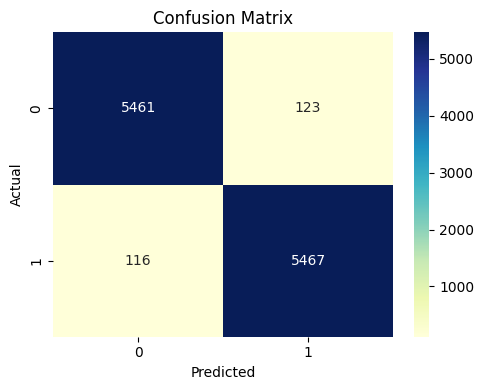

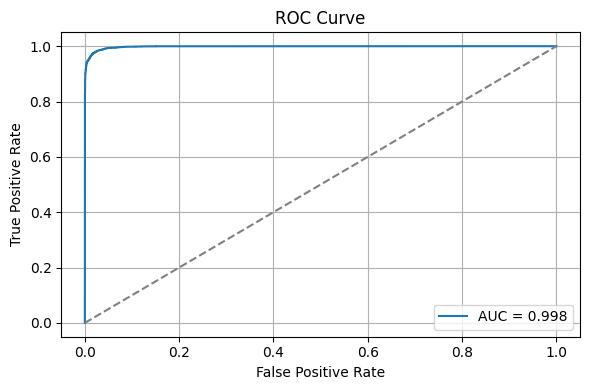

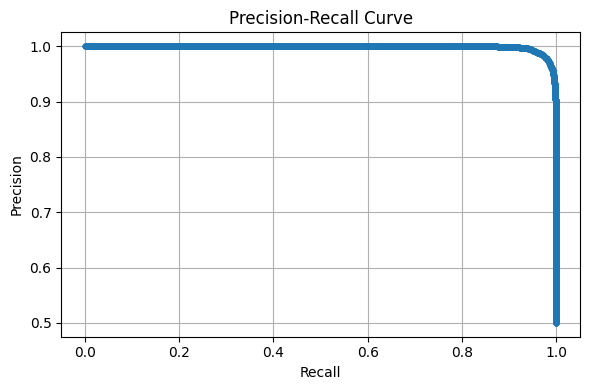

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


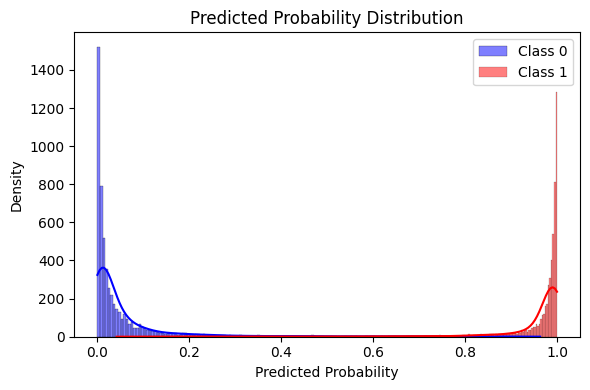

In [37]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Compute predictions & scores
base_test_preds = [model.predict_proba(X_test_balanced)[:, 1] for _, model in base_models]
meta_test_X = np.column_stack(base_test_preds)
y_scores = meta_model.predict_proba(meta_test_X)[:, 1]
final_preds = (y_scores >= best_thresh).astype(int)

# Plot 1: Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test_balanced, final_preds), annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test_balanced, y_scores)
roc_auc = roc_auc_score(y_test_balanced, y_scores)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_balanced, y_scores)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, marker='.')
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 4: Predicted Probability Distribution
plt.figure(figsize=(6, 4))
sns.histplot(y_scores[y_test_balanced == 0], color='blue', label='Class 0', kde=True)
sns.histplot(y_scores[y_test_balanced == 1], color='red', label='Class 1', kde=True)
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


### Save Trained Model  
Exports the trained XGBoost model to disk for future inference or deployment.


In [39]:
import joblib
import os

# Create output directory if it doesn't exist
os.makedirs("/kaggle/working/models", exist_ok=True)

# Save base models
for name, model in base_models:
    joblib.dump(model, f"/kaggle/working/models/base_model_{name}.pkl")
    print(f"Saved base model: {name}")

# Save meta model
joblib.dump(meta_model, "/kaggle/working/models/meta_model_xgb.pkl")
print("Meta-model saved successfully to /kaggle/working/models")


Saved base model: log_reg
Saved base model: random_forest
Saved base model: gbc
Meta-model saved successfully to /kaggle/working/models


## Interpret Model Predictions with SHAP

This section uses SHAP (SHapley Additive exPlanations) to interpret the meta-learner’s predictions. A summary plot shows the global impact of each base model's output on the final prediction, providing insights into model behavior and feature importance.


Explaining model predictions with SHAP...


100%|===================| 11149/11167 [04:29<00:00]        

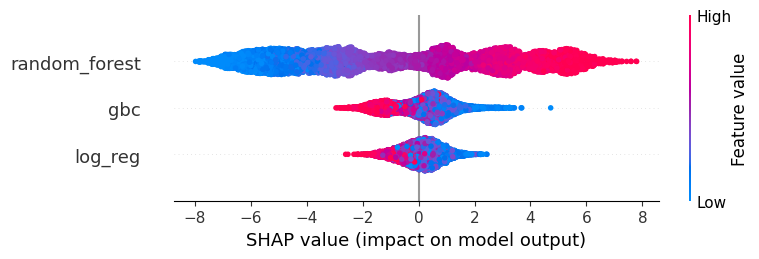

In [13]:
import shap

print("Explaining model predictions with SHAP...")

# Use meta_X from earlier (the stacked feature set)
explainer = shap.Explainer(meta_model, meta_X)
shap_values = explainer(meta_X)

# Global explanation
shap.summary_plot(shap_values, features=meta_X, feature_names=[name for name, _ in base_models])


## Explain Individual Prediction with LIME

This section uses LIME (Local Interpretable Model-agnostic Explanations) to explain a single prediction made by the stacked model. It highlights the contribution of each meta-feature (base model output) to the final decision for a specific test sample.


In [ ]:
import lime
import lime.lime_tabular

print("Explaining a prediction with LIME...")

# Build explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=meta_X,
    feature_names=[name for name, _ in base_models],
    class_names=['No Sepsis', 'Sepsis'],
    mode='classification'
)

# Pick a test sample
sample_index = 5  # Choose any valid index
lime_exp = lime_explainer.explain_instance(meta_test_X[sample_index], meta_model.predict_proba)

# Show explanation in notebook
lime_exp.show_in_notebook(show_table=True)


Explaining a prediction with LIME...


### Prepare Data for Survival Analysis  
Simulates time-to-event data and defines an event indicator to enable survival modeling using the Cox Proportional Hazards framework.


In [15]:
import numpy as np
from lifelines import CoxPHFitter

print("Preparing data for survival analysis...")

X_surv = X_scaled.copy()
np.random.seed(42)
X_surv['duration'] = np.random.randint(1, 100, size=len(X_surv))  # simulated time-to-event
X_surv['event'] = y.values  # 1 = event occurred (e.g. sepsis), 0 = censored

print("Sample survival data:")
print(X_surv.head())


Preparing data for survival analysis...
Sample survival data:
   Unnamed: 0      Hour        HR     O2Sat      Temp       SBP       MAP  \
0   -0.882635 -0.882635 -0.059244  0.254653  0.017198 -0.109313 -0.137238   
1   -0.848012 -0.848012 -1.183861  0.981435  0.017198 -0.109313 -0.659735   
2   -0.813389 -0.813389 -0.393590  0.981435  0.017198 -0.109313 -2.586445   
3   -0.778766 -0.778766 -0.697540  0.981435  0.017198 -0.109313 -0.137238   
4   -0.744143 -0.744143 -0.879911  0.981435  0.017198  0.262891 -0.529111   

        DBP      Resp     EtCO2  ...  Platelets       Age   Gender     Unit1  \
0 -0.108390 -0.130901  0.001026  ...  -0.034967  0.398538 -1.12648 -0.655897   
1 -0.108390 -0.450200  0.001026  ...  -0.034967  0.398538 -1.12648 -0.655897   
2 -0.108390 -0.130901  0.001026  ...  -0.034967  0.398538 -1.12648 -0.655897   
3 -0.108390 -0.343767  0.001026  ...  -0.034967  0.398538 -1.12648 -0.655897   
4  0.495331 -0.982365  0.001026  ...   5.806531  0.398538 -1.12648 -0.65589

### Load and Preprocess Dataset  
Loads the dataset, removes non-essential columns, imputes missing values using the median, and standardizes features for modeling.


In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("Loading dataset...")
df = pd.read_csv("/kaggle/input/prediction-of-sepsis/Dataset.csv")
print(f"Dataset loaded successfully. Shape: {df.shape}")

# Drop unused columns
print("Dropping unused columns (if present)...")
df = df.drop(columns=['patient_id', 'timestamp_epoch', 'datetime'], errors='ignore')
print(f"Remaining columns: {df.columns.tolist()}")

# Separate features and label
print("Separating features and target...")
X_raw = df.drop(columns=['SepsisLabel'])
y = df['SepsisLabel']
print(f"Features shape: {X_raw.shape}, Target shape: {y.shape}")

# Handle missing values
print("Imputing missing values with median strategy...")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)
print("Missing value imputation complete.")

# Scale features
print("Scaling features using StandardScaler...")
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)
print("Feature scaling complete.")

print(" Data preprocessing completed successfully!")


Loading dataset...
Dataset loaded successfully. Shape: (1552210, 44)
Dropping unused columns (if present)...
Remaining columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']
Separating features and target...
Features shape: (1552210, 43), Target shape: (1552210,)
Imputing missing values with median strategy...
Missing value imputation complete.
Scaling features using StandardScaler...
Feature scaling complete.
 Data preprocessing completed successfully!


### Simulate Duration for Survival Analysis  
Loads the dataset, drops unused columns, and simulates time-to-event data to support survival analysis tasks.


In [1]:
import pandas as pd
import numpy as np

print("Loading dataset...")
df = pd.read_csv("/kaggle/input/prediction-of-sepsis/Dataset.csv")
print("Initial shape:", df.shape)

# Drop non-feature columns (if any)
df = df.drop(columns=['patient_id', 'datetime', 'timestamp_epoch'], errors='ignore')

# Define label
event_col = 'SepsisLabel'

# Simulate duration (e.g., time until diagnosis or monitoring window)
np.random.seed(42)
df['duration'] = np.random.randint(30, 100, size=len(df))  # Simulated hours/days

# Final dataset
print("Prepared dataset:")
print(df[[event_col, 'duration']].head())


Loading dataset...
Initial shape: (1552210, 44)
Prepared dataset:
   SepsisLabel  duration
0            0        81
1            0        44
2            0        90
3            0        50
4            0        53


### Preprocess Features for Survival Model  
Handles missing values and standardizes features, then combines them with survival time and event indicator for model input.


In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("Preprocessing features...")

X_raw = df.drop(columns=['SepsisLabel', 'duration'])
y = df[[event_col, 'duration']]

# Handle missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)

# Combine features + target
X_scaled['duration'] = y['duration']
X_scaled['SepsisLabel'] = y[event_col]

print("Preprocessing complete. Final shape:", X_scaled.shape)


Preprocessing features...
Preprocessing complete. Final shape: (1552210, 45)


In [4]:
!pip install lifelines --quiet


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 7.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 6.8 MB/s eta 0:00:00


### Fit Weibull AFT Survival Model  
Trains a Weibull Accelerated Failure Time (AFT) model on the processed dataset to estimate time-to-event (sepsis onset) relationships.


In [ ]:
from lifelines import WeibullAFTFitter

print("Fitting Weibull AFT survival regression model...")

aft = WeibullAFTFitter()
aft.fit(X_scaled, duration_col='duration', event_col='SepsisLabel')

aft.print_summary()  # Shows coefficients and time ratio effects


Fitting Weibull AFT survival regression model...


<lifelines.WeibullAFTFitter: fitted with 1.55221e+06 total observations, 1.52429e+06 right-censored observations>
             duration col = 'duration'
                event col = 'SepsisLabel'
   number of observations = 1.55221e+06
number of events observed = 27916
           log-likelihood = -225366.90
         time fit was run = 2025-05-20 07:26:41 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                         
lambda_ AST              -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
        Age              -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
        Alkalinephos     -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        BUN              -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
        BaseExcess        0.00      1.00      0.00            0.00            0.01                1.00                1.01
        Bilirubin_direct -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
        Bilirubin_total  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        Calcium           0.02      1.02      0.00            0.02            0.03                1.02                1.03
        Chloride         -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
        Creatinine       -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
        DBP               0.02      1.02      0.00            0.01            0.02                1.01                1.02
        EtCO2             0.01      1.01      0.00            0.01            0.01                1.01                1.01
        FiO2             -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        Fibrinogen       -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
        Gender           -0.01      0.99      0.00           -0.02           -0.01                0.98                0.99
        Glucose          -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
        HCO3              0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        HR               -0.07      0.94      0.00           -0.07           -0.06                0.93                0.94
        Hct              -0.01      0.99      0.00           -0.02           -0.00                0.98                1.00
        Hgb               0.01      1.01      0.00            0.00            0.01                1.00                1.02
        HospAdmTime       0.01      1.01      0.00            0.01            0.01                1.01                1.01
        Hour             -0.03      0.97  32767.99       -64224.11        64224.05                0.00                 inf
        ICULOS           -0.04      0.96      0.01           -0.06           -0.02                0.94                0.98
        Lactate          -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
        MAP               0.03      1.03      0.00            0.02            0.03                1.02                1.03
        Magnesium         0.00      1.00      0.00           -0.00            0.01                1.00                1.01
        O2Sat            -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        PTT              -0.01      0.99      0.00           -0.01  

### Predict Time to Sepsis Using AFT Model  
Generates median predicted survival times for each patient, representing the estimated time to sepsis onset.


In [6]:
print("Predicting expected time to sepsis...")

# Remove label/duration to form prediction set
X_predict = X_scaled.drop(columns=['duration', 'SepsisLabel'])

# Predict expected survival time (median)
predicted_times = aft.predict_median(X_predict)

# Show results for first 10 patients
prediction_df = df.copy()
prediction_df['Predicted_Sepsis_Time'] = predicted_times.round(2)

print("Sample predictions (in hours/days):")
print(prediction_df[['SepsisLabel', 'Predicted_Sepsis_Time']].head(10))


Predicting expected time to sepsis...
Sample predictions (in hours/days):
   SepsisLabel  Predicted_Sepsis_Time
0            0                 227.73
1            0                 243.97
2            0                 217.40
3            0                 236.89
4            0                 251.03
5            0                 261.99
6            0                 247.82
7            0                 275.77
8            0                 248.71
9            0                 254.49


### Example Prediction for a Patient  
Displays the actual and predicted time to sepsis for a selected patient from the dataset.


In [7]:
example_idx = 3  # Pick any row to demonstrate
actual = prediction_df.iloc[example_idx]['SepsisLabel']
pred_time = prediction_df.iloc[example_idx]['Predicted_Sepsis_Time']

print(f"Patient {example_idx}:")
print(f"  Sepsis event occurred? {'Yes' if actual == 1 else 'No'}")
print(f"  Predicted time to sepsis (or observation end): {pred_time} hours/days")


Patient 3:
  Sepsis event occurred? No
  Predicted time to sepsis (or observation end): 236.89 hours/days


### Visualize Survival Curves for a Covariate  
Plots the effect of different values of a selected feature on the predicted survival probability over time using the Weibull AFT model.


Plotting survival function based on a single covariate...


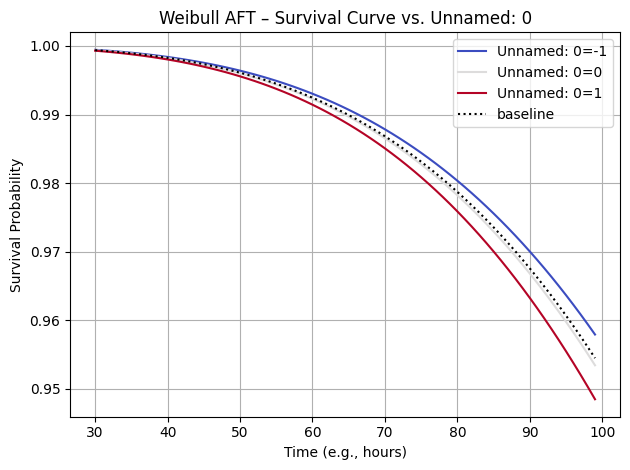

In [ ]:
import matplotlib.pyplot as plt

print("Plotting survival function based on a single covariate...")


covariate_name = X_predict.columns[0]  
values_to_test = [-1, 0, 1]  
aft.plot_partial_effects_on_outcome(
    covariates=covariate_name,
    values=values_to_test,
    cmap='coolwarm'
)

plt.title(f"Weibull AFT – Survival Curve vs. {covariate_name}")
plt.xlabel("Time (e.g., hours)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.tight_layout()
plt.show()


### Plot Top Influential Features from AFT Model  
Displays the top five features with the greatest impact on predicted survival time based on the Weibull AFT model's coefficients.


Plotting top 5 influential features based on time ratios...


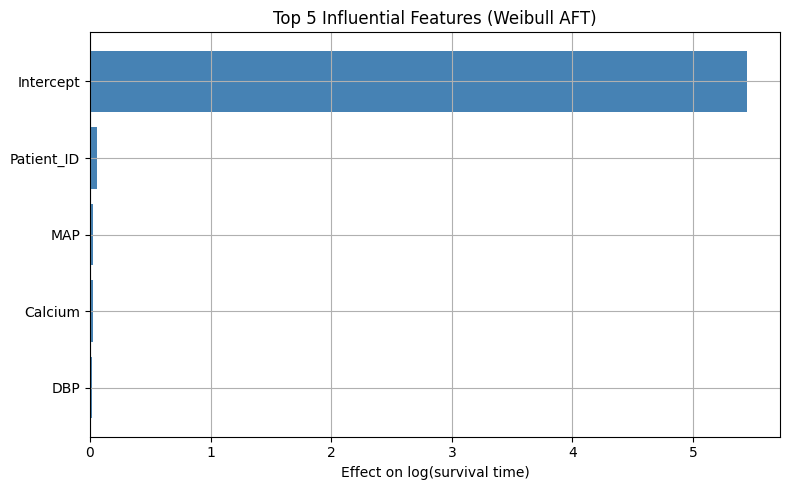

In [11]:
import matplotlib.pyplot as plt

print("Plotting top 5 influential features based on time ratios...")

# Filter to 'lambda_' coefficients only (ignores intercepts and scale parameters)
lambda_coefs = aft.summary.loc[aft.summary.index.get_level_values(0) == 'lambda_']
lambda_coefs = lambda_coefs.sort_values(by='coef', ascending=False)

# Extract clean feature names
top_features = lambda_coefs.head(5)
feature_names = [i[1] for i in top_features.index]

plt.figure(figsize=(8, 5))
plt.barh(feature_names[::-1], top_features['coef'][::-1], color='steelblue')
plt.xlabel("Effect on log(survival time)")
plt.title("Top 5 Influential Features (Weibull AFT)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Plot Survival Curves for Random Patients  
Generates individual survival curves for three randomly selected patients to illustrate predicted time-to-sepsis variability.


Plotting survival curves for 3 random patients...


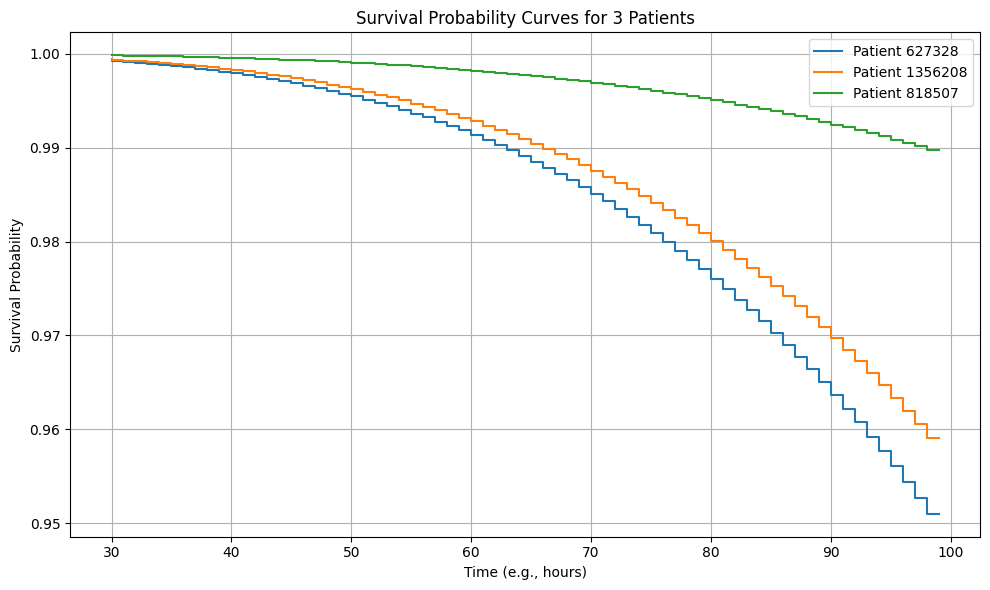

In [12]:
print("Plotting survival curves for 3 random patients...")

sample_indices = np.random.choice(X_predict.index, size=3, replace=False)

plt.figure(figsize=(10, 6))
for i in sample_indices:
    surv_fn = aft.predict_survival_function(X_predict.iloc[[i]])
    plt.step(surv_fn.index, surv_fn.values.flatten(), label=f'Patient {i}')

plt.title("Survival Probability Curves for 3 Patients")
plt.xlabel("Time (e.g., hours)")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Plot Distribution of Predicted Sepsis Times  
Displays a histogram showing how predicted times to sepsis are distributed across the patient population.


Plotting histogram of predicted time to sepsis...


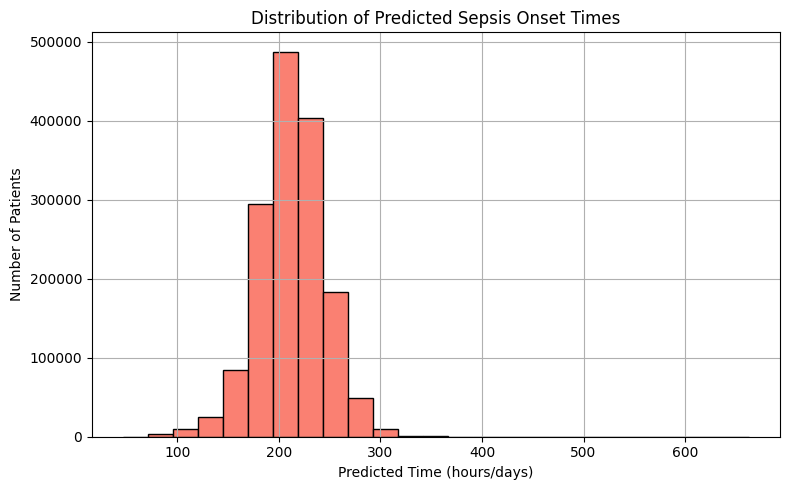

In [13]:
print("Plotting histogram of predicted time to sepsis...")

plt.figure(figsize=(8, 5))
plt.hist(predicted_times, bins=25, color='salmon', edgecolor='black')
plt.title("Distribution of Predicted Sepsis Onset Times")
plt.xlabel("Predicted Time (hours/days)")
plt.ylabel("Number of Patients")
plt.grid(True)
plt.tight_layout()
plt.show()


### Compare Actual vs Predicted Sepsis Times  
Creates a summary table comparing actual sepsis events with predicted time-to-sepsis and observed durations for a sample of patients.


In [14]:
print("Displaying sample predictions (actual vs predicted time)...")

comparison_df = df[['SepsisLabel']].copy()
comparison_df['Predicted_Sepsis_Time'] = predicted_times.round(2)
comparison_df['Simulated_Observed_Duration'] = df['duration']

# Show top 10 rows
print(comparison_df.head(10))


Displaying sample predictions (actual vs predicted time)...
   SepsisLabel  Predicted_Sepsis_Time  Simulated_Observed_Duration
0            0                 227.73                           81
1            0                 243.97                           44
2            0                 217.40                           90
3            0                 236.89                           50
4            0                 251.03                           53
5            0                 261.99                           32
6            0                 247.82                           51
7            0                 275.77                           82
8            0                 248.71                           31
9            0                 254.49                           59


### Individual Patient Prediction Summary  
Outputs actual event status, predicted sepsis onset time, and observed monitoring duration for a selected patient.


In [15]:
example_idx = 7  # Change index to analyze a different patient

# Extract actual and predicted details
actual_event = comparison_df.iloc[example_idx]['SepsisLabel']
predicted_time = comparison_df.iloc[example_idx]['Predicted_Sepsis_Time']
observed_time = comparison_df.iloc[example_idx]['Simulated_Observed_Duration']

# Display result
print(f"Patient {example_idx} Prediction Summary")
print("-" * 40)
print(f"Actual Sepsis Event:        {'Yes' if actual_event == 1 else 'No'}")
print(f"Predicted Time to Sepsis:   {predicted_time} hours/days")
print(f"Observed Monitoring Time:   {observed_time} hours/days")


Patient 7 Prediction Summary
----------------------------------------
Actual Sepsis Event:        No
Predicted Time to Sepsis:   275.77 hours/days
Observed Monitoring Time:   82.0 hours/days
